In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from scipy.stats import f_oneway, kruskal
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from itertools import product 
from time import time

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from utils.analysis import get_query_string_hyps_filter, load_dbscan_labels

# Feature Importance Analysis
&#8594; Determine whether the mean values of the scaled parameters differ significantly across clusters 

In [2]:
# Load data
df_in = pd.read_csv(f"{config.output_dir}wide_table_knn.csv") 
df = df_in.drop(["LATITUDE", "LONGITUDE", "LEV_M", "imputed", "water"], axis=1)  # Remove unneeded information

In [3]:
# Scale data
scaler = MinMaxScaler().fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)

# Combine dataframes
df_total = df_in.copy()
for p in ["P_TEMPERATURE", "P_SALINITY", "P_OXYGEN", "P_NITRATE", "P_SILICATE", "P_PHOSPHATE"]:
    df_total[p + "_scaled"] = df_scaled[p]

In [4]:
# Load clustering results
#df_kmeans = pd.read_csv(f"{config.output_dir_clustering}/labels_kmeans.csv")
#df_ward = pd.read_csv(f"{config.output_dir_clustering}/labels_ward.csv")
#df_dbscan = pd.read_csv(f"{config.output_dir_clustering}/labels_dbscan_iteration0.csv")

In [5]:
# TEMPORARY TO DO REMOVE
# Load clustering results
# df_kmeans = pd.read_csv(f"output/clustering_old/labels_kmeans.csv")
# df_ward = pd.read_csv(f"output/clustering_old/labels_ward.csv")
# df_dbscan = pd.read_csv(f"output/clustering_old/labels_dbscan_iteration0.csv")

In [6]:
def rf(df, x_columns, y_column="label"):
    """ Train a random forest to mimic a clustering model. """
    X = df[x_columns]
    y = df[y_column]
    rf_results = []

    # Train a random forest
    rf_clf = RandomForestClassifier(random_state=42,   
                                    oob_score=True,
                                    #max_features=0.5,        # Control feature selection per split
                                    #min_samples_leaf=3,      # Avoid overfitting by limiting leaf size
                                    #max_depth=None,          # Allow deep trees for complex separations
                                    n_estimators=1000,        # More trees to improve robustness (some clusters are challenging to separate, small clusters)
                                    class_weight="balanced")  # Ensure that small clusters contribute equally to decision
    rf_clf.fit(X, y)
    
    # Get feature importance
    rf_importance = rf_clf.feature_importances_
    
    # Display results
    for param, importance in zip(X.columns, rf_importance):
        rf_results.append(pd.DataFrame({"parameter": [param], "importance": [importance], "oob": [rf_clf.oob_score_]}))

    return pd.concat(rf_results).sort_values("importance", ascending=False).reset_index(drop=True)

In [7]:
# Training and UMAP columns
x_cols = ['P_TEMPERATURE_scaled', 'P_SALINITY_scaled', 'P_OXYGEN_scaled', 'P_NITRATE_scaled', 'P_SILICATE_scaled', 'P_PHOSPHATE_scaled']
umap_cols = [f"e{i}" for i in range(hyp_config.umap_hyps["n_components"])]

## KMeans

In [21]:
# On original data
preprocessing = "minmax"
query_str = " & ".join([f"{k} == {v!r}" for k, v in hyp_config.kmeans_original_hyps.items()]) + f" & iteration==0 & preprocessing=='{preprocessing}'"

# Get labels
temp = df_kmeans.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
temp = df_total.merge(temp, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

True


In [22]:
rf_kmeans_original = rf(temp, x_columns=x_cols)
rf_kmeans_original

,parameter,importance,oob
0,P_TEMPERATURE_scaled,0.476270,0.996288
1,P_SALINITY_scaled,0.230315,0.996288
2,P_OXYGEN_scaled,0.165953,0.996288
3,P_PHOSPHATE_scaled,0.065745,0.996288
4,P_NITRATE_scaled,0.039825,0.996288
5,P_SILICATE_scaled,0.021892,0.996288


In [34]:
# On embedded data
preprocessing = "minmax_umap"
query_str = " & ".join([f"{k} == {v!r}" for k, v in hyp_config.kmeans_umap_hyps.items()]) + f" & iteration==0 & preprocessing=='{preprocessing}'"

# Get labels
temp = df_kmeans.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"] + umap_cols]

# Add parameter information
temp = df_total.merge(temp, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

True


In [36]:
rf_kmeans_embedding = rf(temp, x_columns=x_cols)
rf_kmeans_embedding

,parameter,importance,oob
0,P_TEMPERATURE_scaled,0.328138,0.983928
1,P_OXYGEN_scaled,0.229886,0.983928
2,P_SALINITY_scaled,0.176795,0.983928
3,P_NITRATE_scaled,0.136326,0.983928
4,P_PHOSPHATE_scaled,0.064720,0.983928
5,P_SILICATE_scaled,0.064135,0.983928


## Ward

In [8]:
# On original data
preprocessing = "minmax"
query_str = " & ".join([f"{k} == {v!r}" for k, v in hyp_config.ward_original_hyps.items()]) + f" & iteration==0 & preprocessing=='{preprocessing}'"

# Get labels
temp = df_ward.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
temp = df_total.merge(temp, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

True


In [10]:
rf_ward_original = rf(temp, x_columns=x_cols)
rf_ward_original

,parameter,importance,oob
0,P_TEMPERATURE_scaled,0.348728,0.996268
1,P_OXYGEN_scaled,0.340607,0.996268
2,P_SALINITY_scaled,0.158439,0.996268
3,P_PHOSPHATE_scaled,0.072081,0.996268
4,P_NITRATE_scaled,0.064070,0.996268
5,P_SILICATE_scaled,0.016076,0.996268


In [11]:
# On embedded data
preprocessing = "minmax_umap"
query_str = " & ".join([f"{k} == {v!r}" for k, v in hyp_config.ward_umap_hyps.items()]) + f" & iteration==0 & preprocessing=='{preprocessing}'"

# Get labels
temp = df_ward.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"] + umap_cols]

# Add parameter information
temp = df_total.merge(temp, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

True


In [12]:
rf_ward_embedding = rf(temp, x_columns=x_cols)
rf_ward_embedding

,parameter,importance,oob
0,P_TEMPERATURE_scaled,0.319241,0.975382
1,P_OXYGEN_scaled,0.234153,0.975382
2,P_SALINITY_scaled,0.163271,0.975382
3,P_NITRATE_scaled,0.120232,0.975382
4,P_SILICATE_scaled,0.093125,0.975382
5,P_PHOSPHATE_scaled,0.069979,0.975382


## All hyperparameters and algorithms

In [ ]:
# Feature importance for all hyperparameter combinations
for cluster_name, (ClusterAlgo, param_grid) in config.algorithms_and_hyps.items():
    print(cluster_name)
    
    # Generate all hyperparameter combinations
    hyp_param_combinations = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

    # Load data
    print(f"Load data for {cluster_name}...")
    if cluster_name != "dbscan": 
        data_file = f"{config.output_dir_clustering}/labels_{cluster_name}.csv"
        df_feature_importance = pd.read_csv(data_file)
    
    # Iterate over iterations
    for i in range(config.n_iterations): 
        print(f"  Iteration {i}")

        # For DBSCAN, we need to load each iteration separately
        if cluster_name == "dbscan": 
            print("  Loading DBSCAN data...")
            df_feature_importance = load_dbscan_labels(iteration=i)

        # Iterate over hyperparameter combinations
        for hyp_params in hyp_param_combinations:
                
            filename = f"{config.output_dir_feature_importance}feature_importance_iteration{i}_{cluster_name}_{'_'.join([f'{k}{v}' for k, v in hyp_params.items()])}.csv"
            
            # Only compute if it has not been done before 
            if not Path(filename).exists():
                print(f"    Now computing: {filename}")
                res = []
                
                # Iterate over prepprocessings
                for preprocessing in config.preprocessings.keys():                    
                    # Get labels
                    start_time = time()
                    query_str = get_query_string_hyps_filter(hyp_params, preproc=preprocessing) + f"& iteration=={i}"
                    temp = df_feature_importance.query(query_str)[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

                    # Add parameter information
                    temp = df_total.merge(temp, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")

                    # Train RF
                    forest = rf(temp, x_columns=x_cols)  
                    end_time = time()

                    # Append results
                    forest_dict = forest.to_dict()
                    forest_flat = [
                        {"parameter": forest_dict["parameter"][i],
                         "importance": forest_dict["importance"][i],
                         "oob": forest_dict["oob"][i]}
                        for i in forest_dict["parameter"]
                    ]
                    for row in forest_flat:
                        res.append({**{
                            "iteration": i,
                            "preprocessing": preprocessing,
                            "clustering": cluster_name,
                            "feature importance_time": end_time - start_time,
                        }, **hyp_params, **row})

                # Store results (in one file, we will have both preprocessings)
                res = pd.DataFrame(res)
                res.to_csv(filename, index=False)
            else:
                print(f"Skipping. File already exists: {filename}")

In [ ]:
# Store feature importance results (and remove temporary files)
for cluster_name in config.algorithms_and_hyps.keys():
    print(cluster_name)

    res = []
    files_to_remove = []
    
    for file in Path(config.output_dir_feature_importance).glob(f"{config.output_dir.feature_importance}feature_importance_{cluster_name}_*.csv"):
        res.append(pd.read_csv(file))
        files_to_remove.append(file)
    
    # Store results
    res = pd.concat(res)
    res.to_csv(f"{config.output_dir_feature_importance}feature_importance_{cluster_name}.csv", index=False)
    
    # Remove temporary files
    for file in files_to_remove:
        if file.exists():  
            file.unlink()

## DBSCAN

In [23]:
# On original data
eps = hyp_config.dbscan_original_hyps["eps"]
min_samples = hyp_config.dbscan_original_hyps["min_samples"]
preprocessing = "minmax"

# Get labels
temp = df_dbscan[(df_dbscan.eps.round(8) == round(eps, 8)) & (df_dbscan.min_samples == min_samples) & (df_dbscan.preprocessing == preprocesing)][["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
# temp = df_total.merge(filtered, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

49131


In [26]:
rf_dbscan_original = rf(temp, x_columns=x_cols)
rf_dbscan_original

,parameter,importance,oob
0,P_SALINITY_scaled,0.339458,0.998819
1,P_SILICATE_scaled,0.190595,0.998819
2,P_OXYGEN_scaled,0.161093,0.998819
3,P_PHOSPHATE_scaled,0.120001,0.998819
4,P_TEMPERATURE_scaled,0.100792,0.998819
5,P_NITRATE_scaled,0.088061,0.998819


In [27]:
# On embedded data
eps = hyp_config.dbscan_umap_hyps["eps"]
min_samples = hyp_config.dbscan_umap_hyps["min_samples"]
preprocessing = "minmax_umap"

# Get labels
temp = df_dbscan[(df_dbscan.eps.round(8) == round(eps, 8)) & (df_dbscan.min_samples == min_samples) & (df_dbscan.preprocessing == preprocesing)][["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
# temp = df_total.merge(filtered, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

49131


In [30]:
rf_dbscan_embedding = rf(temp, x_columns=x_cols)
rf_dbscan_embedding

,parameter,importance,oob
0,P_TEMPERATURE_scaled,0.230223,0.915166
1,P_OXYGEN_scaled,0.225461,0.915166
2,P_PHOSPHATE_scaled,0.170689,0.915166
3,P_SILICATE_scaled,0.137053,0.915166
4,P_SALINITY_scaled,0.127653,0.915166
5,P_NITRATE_scaled,0.108920,0.915166


## Final clustering (NEMI)

In [31]:
df_final = pd.read_csv(f"{config.output_dir_nemi}/volume_nemi_iteration67.csv").drop(["label", "sorted_label"], axis=1).rename(columns={"label_color": "color", "final_label": "label"})

In [32]:
# Get labels
temp = df_final[["label", "LATITUDE", "LONGITUDE", "LEV_M"]]

# Add parameter information
# temp = df_total.merge(filtered, on=["LATITUDE", "LONGITUDE", "LEV_M"], how="outer")
print(len(temp) == 49030)

49131


In [35]:
rf_final = rf(temp, x_columns=x_cols)
rf_final

,parameter,importance,oob
0,P_OXYGEN_scaled,0.237402,0.927032
1,P_TEMPERATURE_scaled,0.233317,0.927032
2,P_PHOSPHATE_scaled,0.166931,0.927032
3,P_SILICATE_scaled,0.132874,0.927032
4,P_SALINITY_scaled,0.124179,0.927032
5,P_NITRATE_scaled,0.105296,0.927032


In [38]:
# Concatenate results
algorithms = ["kmeans", "kmeans", "ward", "ward", "dbscan", "dbscan", "nemi"]
data_array = ["minmax", "minmax_umap", "minmax", "minmax_umap", "minmax", "minmax_umap", "minmax_umap"]

In [41]:
df_rf = pd.DataFrame(columns=["algorithm", "data", "parameter", "f", "p"])

rows = []
for temp, algo, data in zip([rf_kmeans_original, rf_kmeans_embedding, rf_ward_original, rf_ward_embedding, rf_dbscan_original, rf_dbscan_embedding, rf_final], 
                          algorithms, data_array):
    temp["algorithm"] = algo
    temp["data"] = data
    rows.append(temp)

df_rf = pd.concat(rows).reset_index(drop=True)

In [31]:
df_rf.to_csv(output_dir + "feature_importance.csv", index=False)

NameError: name 'df_rf' is not defined

## Visualisation

In [6]:
# Viz
df_rf = pd.read_csv("feature_importance.csv")
df_rf['parameter'] = df_rf['parameter'].replace({'P_TEMPERATURE_scaled': 'Temperature', 'P_SALINITY_scaled': 'Salinity', 'P_OXYGEN_scaled': 'Oxygen',
                           'P_NITRATE_scaled': 'Nitrate', 'P_SILICATE_scaled': 'Silicate', 'P_PHOSPHATE_scaled': 'Phosphate'})

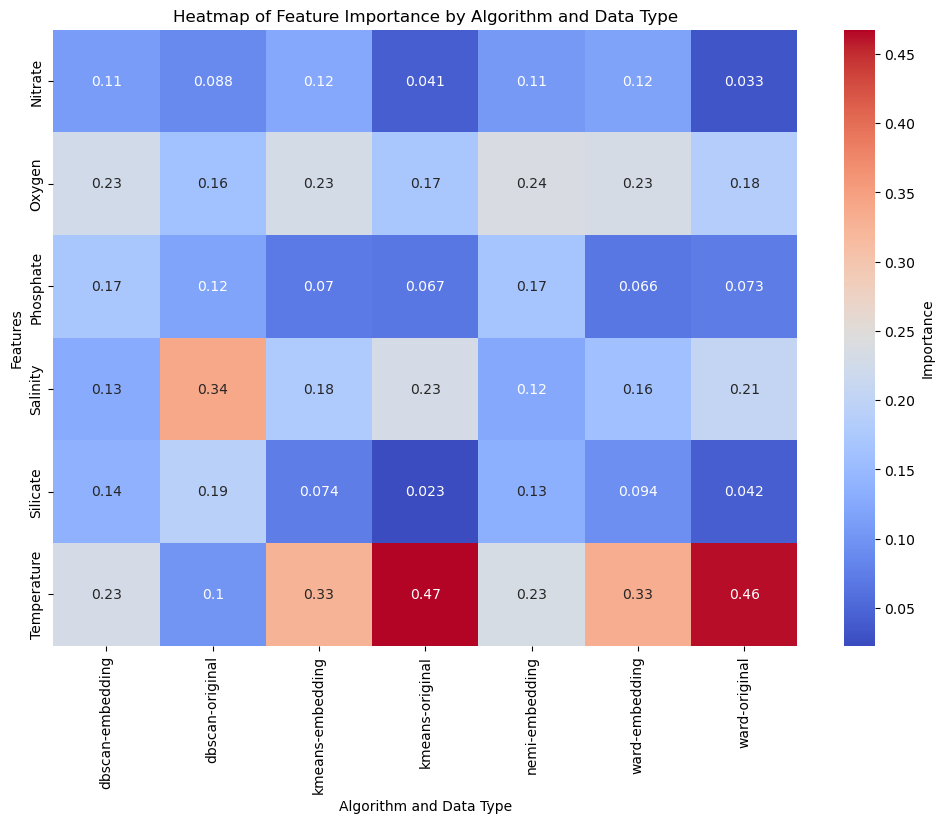

In [7]:
heatmap_data = df_rf.pivot_table(index="parameter", columns=["algorithm", "data"], values="importance", aggfunc="mean")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", cbar_kws={'label': 'Importance'})
plt.title("Heatmap of Feature Importance by Algorithm and Data Type")
plt.xlabel("Algorithm and Data Type")
plt.ylabel("Features")
plt.show()

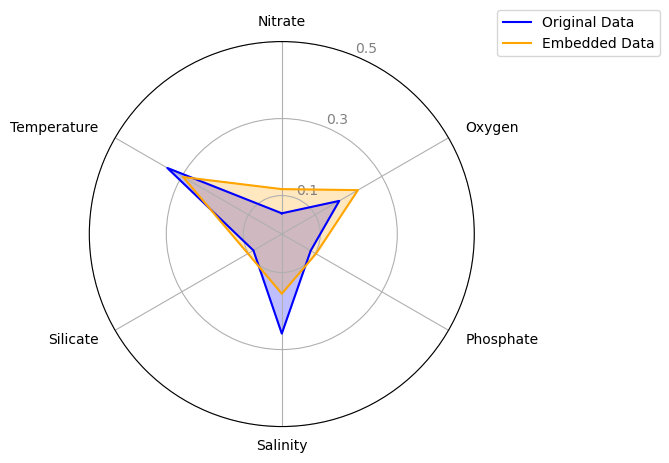

In [8]:
temp = df_rf[df_rf.algorithm != "nemi"]

# Compute mean importance by data type
radar_data = temp[['parameter', 'importance', 'data']].groupby(["parameter", "data"]).mean().reset_index()
radar_original = radar_data[radar_data["data"] == "original"].set_index("parameter")["importance"]
radar_embedded = radar_data[radar_data["data"] == "embedding"].set_index("parameter")["importance"]

# Radar chart preparation
categories = radar_original.index.tolist()
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Plot
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.plot(angles, radar_original.tolist() + radar_original[:1].tolist(), label="Original Data", color="blue")
ax.fill(angles, radar_original.tolist() + radar_original[:1].tolist(), alpha=0.25, color="blue")
ax.plot(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), label="Embedded Data", color="orange")
ax.fill(angles, radar_embedded.tolist() + radar_embedded[:1].tolist(), alpha=0.25, color="orange")

# Formatting
# ax.set_title("Feature Importance Distribution: Original vs. Embedded Data")#, size=10, pad=20)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, ha='center')  # You can change fontsize or alignment for clarity

# Use external padding for labels
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (0, np.pi):  # Top and bottom labels
        label.set_verticalalignment('center')
    elif 0 < angle < np.pi:  # Right-side labels
        label.set_horizontalalignment('left')
    else:  # Left-side labels
        label.set_horizontalalignment('right')
        
ax.set_yticks([0.1, 0.3, 0.5])
ax.set_yticklabels(["0.1", "0.3", "0.5"], color="gray")#, size=10)
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.1))

#plt.tight_layout()
plt.savefig(output_dir_high_res + "feature_importance_data_comparison.png", bbox_inches="tight", dpi=1000)
plt.show()